# Installing the required libraries

In [ ]:
!pip install numpy pandas jovian opendatasets scikit-learn xgboost --quiet

In [ ]:
import opendatasets as od

In [ ]:
dataset_url = 'https://www.kaggle.com/competitions/new-york-city-taxi-fare-prediction/data'

In [ ]:
!pip install kaggle -q

In [ ]:
kagglehub.login()

In [ ]:
import kagglehub

# This downloads the competition files to a local path in Colab
path = kagglehub.competition_download('new-york-city-taxi-fare-prediction')

print("Data downloaded to:", path)

100%|██████████| 1.56G/1.56G [00:20<00:00, 82.8MB/s]

Extracting files...


Data downloaded to: /root/.cache/kagglehub/competitions/new-york-city-taxi-fare-prediction


In [ ]:
import shutil
import os

# Moving everything from the download path to my current working directory
for file in os.listdir(path):
    shutil.move(os.path.join(path, file), os.getcwd())

print("Files moved to current directory!")

Files moved to current directory!


In [ ]:
import os
import shutil

# Setting my folder name to 'nyc-taxi-data'
data_dir = 'nyc-taxi-data'

# Creating the directory if it doesn't exist
os.makedirs(data_dir, exist_ok=True)

# Moving the files into the specific directory
for file in ['train.csv', 'test.csv']:
    if os.path.exists(file):
        shutil.move(file, os.path.join(data_dir, file))
        print(f"Moved {file} to {data_dir}/")

Moved train.csv to nyc-taxi-data/
Moved test.csv to nyc-taxi-data/


In [ ]:
data_dir = 'nyc-taxi-data'

# Viewing Data

In [ ]:
!ls -lh {data_dir}

total 5.4G
-rw-r--r-- 1 root root 960K May 14 05:26 test.csv
-rw-r--r-- 1 root root 5.4G May 14 05:27 train.csv


In [ ]:
# No. of lines in training set
!wc -l {data_dir}/train.csv

55423856 nyc-taxi-data/train.csv


In [ ]:
# No. of lines in test set
!wc -l {data_dir}/test.csv

9914 nyc-taxi-data/test.csv


In [ ]:
import os
import shutil
import kagglehub


data_dir = 'nyc-taxi-data'
os.makedirs(data_dir, exist_ok=True)

# Grabbing the raw download directory cache
raw_path = kagglehub.competition_download('new-york-city-taxi-fare-prediction')

# Looking through every folder/subfolder to copy ALL items
for root, dirs, files in os.walk(raw_path):
    for file in files:
        src_file = os.path.join(root, file)

        # Lowercase check to prevent duplicate spelling issues (e.g. Sample_Submission vs sample_submission)
        dest_file = os.path.join(data_dir, file.lower())

        shutil.copy2(src_file, dest_file)
        print(f"Successfully copied: {file} -> {data_dir}/")

# If the name is completely different, let's manually build a fallback sample file so the code never breaks
fallback_sub = os.path.join(data_dir, 'sample_submission.csv')
if not os.path.exists(fallback_sub):
    import pandas as pd
    test_df = pd.read_csv(os.path.join(data_dir, 'test.csv'))
    # Creating the exact sample template structure required by this competition
    sub_df = pd.DataFrame({'key': test_df['key'], 'fare_amount': 11.35})
    sub_df.to_csv(fallback_sub, index=False)
    print("Manually generated missing 'sample_submission.csv' template successfully!")

Manually generated missing 'sample_submission.csv' template successfully!


In [ ]:
# Creating an empty placeholder file
with open('nyc-taxi-data/GCP-Coupons-Instructions.rtf', 'w') as f:
    f.write('Placeholder text')
print("Placeholder file created!")

Placeholder file created!


In [ ]:
!ls -lh {data_dir}

total 5.4G
-rw-r--r-- 1 root root   16 May 14 05:27 GCP-Coupons-Instructions.rtf
-rw-r--r-- 1 root root 336K May 14 05:27 sample_submission.csv
-rw-r--r-- 1 root root 960K May 14 05:26 test.csv
-rw-r--r-- 1 root root 5.4G May 14 05:27 train.csv


In [ ]:
# No. of lines in submission file
!wc -l {data_dir}/sample_submission.csv

9915 nyc-taxi-data/sample_submission.csv


In [ ]:
# Training set
!head {data_dir}/train.csv

key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.84161,40.712278,1
2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.76127,-73.991242,40.750562,2
2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.98713,40.733143,-73.991567,40.758092,1
2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1
2011-01-06 09:50:45.0000002,12.1,2011-01-06 09:50:45 UTC,-74.000964,40.73163,-73.972892,40.758233,1
2012-11-20 20:35:00.0000001,7.5,2012-11-20 20:35:00 UTC,-73.980002,40.751662,-73.973802,40.764842,1
2012-01-04 17:22:00.00000081,16.5,2012-01-04 17:22:00 UTC,-73.9513,40.774138,-73.990095,40.751048,1
2012-12-03 13:10:00.000000125,9,2012-12-03 13:10:00 UTC,-74.006462,40.726713,-73.99

In [ ]:
# Test set
!head {data_dir}/test.csv

key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320007324219,40.7638053894043,-73.981430053710938,40.74383544921875,1
2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862182617188,40.719383239746094,-73.998886108398438,40.739200592041016,1
2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.75126,-73.979654,40.746139,1
2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.98116,40.767807,-73.990448,40.751635,1
2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1
2012-12-01 21:12:12.0000005,2012-12-01 21:12:12 UTC,-73.960983,40.765547,-73.979177,40.740053,1
2011-10-06 12:10:20.0000001,2011-10-06 12:10:20 UTC,-73.949013,40.773204,-73.959622,40.770893,1
2011-10-06 12:10:20.0000003,2011-10-06 12:10:20 UTC,-73.777282,40.646636,-73.985083,40.759368,1
2011-10-06 12:10:20.0000002,2011-10-06 12:10:20 UTC,-74.01409

In [ ]:
# Sample submission file
!head {data_dir}/sample_submission.csv

key,fare_amount
2015-01-27 13:08:24.0000002,11.35
2015-01-27 13:08:24.0000003,11.35
2011-10-08 11:53:44.0000002,11.35
2012-12-01 21:12:12.0000002,11.35
2012-12-01 21:12:12.0000003,11.35
2012-12-01 21:12:12.0000005,11.35
2011-10-06 12:10:20.0000001,11.35
2011-10-06 12:10:20.0000003,11.35
2011-10-06 12:10:20.0000002,11.35


# Loading Training Set

In [ ]:
import pandas as pd
import random

In [ ]:
# Change this
sample_frac = 0.01

In [ ]:
%%time
selected_cols = 'fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count'.split(',')
dtypes = {
    'fare_amount': 'float32',
    'pickup_longitude': 'float32',
    'pickup_latitude': 'float32',
    'dropoff_longitude': 'float32',
    'passenger_count': 'float32'
}

def skip_row(row_idx):
    if row_idx == 0:
        return False
    return random.random() > sample_frac

random.seed(42)
df = pd.read_csv(data_dir+"/train.csv",
                 usecols=selected_cols,
                 dtype=dtypes,
                 parse_dates=['pickup_datetime'],
                 skiprows=skip_row)

CPU times: user 1min 15s, sys: 2.47 s, total: 1min 17s
Wall time: 1min 21s


This is exactly how random.random() interacts with that process:Pandas holds Row 1 at the gate.random.random() rolls a digital 100-sided die.If the die lands on numbers 2 through 100 (99% chance), the function says True (Skip it). Pandas immediately deletes Row 1 from its vision.Pandas moves to Row 2.random.random() rolls the die again.If the die lands on number 1 (1% chance), the function says False (Don't skip it). Pandas lets Row 2 pass through the gate into your notebook's memory.Pandas moves to Row 3 and repeats this for all 55 million rows.

In [ ]:
df.head(10)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.0,2014-12-06 20:36:22+00:00,-73.979813,40.751904,-73.979446,40.755481,1.0
1,8.0,2013-01-17 17:22:00+00:00,0.000000,0.000000,0.000000,0.000000,2.0
2,8.9,2011-06-15 18:07:00+00:00,-73.996330,40.753223,-73.978897,40.766963,3.0
3,6.9,2009-12-14 12:33:00+00:00,-73.982430,40.745747,-73.982430,40.745747,1.0
4,7.0,2013-11-06 11:26:54+00:00,-73.959061,40.781059,-73.962059,40.768604,1.0
5,15.5,2014-12-08 01:00:16+00:00,-73.957672,40.717888,-73.942581,40.686397,1.0
6,6.0,2012-09-26 13:14:47+00:00,-73.964485,40.764431,-73.956573,40.779852,1.0
7,21.0,2014-01-29 22:41:00+00:00,-73.978554,40.766716,-74.016197,40.711052,6.0
8,20.5,2012-09-13 11:31:00+00:00,-73.986458,40.751526,-73.953735,40.787725,1.0
9,16.5,2012-02-21 12:13:11+00:00,-74.010895,40.714424,-73.983368,40.756248,1.0


# Loading the Test Dataset

In [ ]:
test_df = pd.read_csv(data_dir+'/test.csv', dtype=dtypes, parse_dates=['pickup_datetime'])
test_df.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1.0
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1.0
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746139,1.0
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751635,1.0
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1.0


# Performing EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552450 entries, 0 to 552449
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        552450 non-null  float32            
 1   pickup_datetime    552450 non-null  datetime64[ns, UTC]
 2   pickup_longitude   552450 non-null  float32            
 3   pickup_latitude    552450 non-null  float32            
 4   dropoff_longitude  552450 non-null  float32            
 5   dropoff_latitude   552450 non-null  float64            
 6   passenger_count    552450 non-null  float32            
dtypes: datetime64[ns, UTC](1), float32(5), float64(1)
memory usage: 19.0 MB


In [ ]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,552450.000000,552450.000000,552450.000000,552450.000000,552450.000000,552450.000000
mean,11.354059,-72.497063,39.910500,-72.504326,39.934257,1.684983
std,9.810809,11.622035,8.041162,12.065184,9.255058,1.341986
min,-52.000000,-1183.362793,-3084.490234,-3356.729736,-2073.150613,0.000000
25%,6.000000,-73.992020,40.734875,-73.991425,40.733988,1.000000
50%,8.500000,-73.981819,40.752621,-73.980179,40.753102,1.000000
75%,12.500000,-73.967155,40.767036,-73.963737,40.768060,2.000000
max,499.000000,2420.209473,404.983337,2467.752686,3351.403027,208.000000


In [ ]:
df.pickup_datetime.min(), df.pickup_datetime.max()

(Timestamp('2009-01-01 00:11:46+0000', tz='UTC'),
 Timestamp('2015-06-30 23:59:54+0000', tz='UTC'))

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9914 entries, 0 to 9913
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   key                9914 non-null   object             
 1   pickup_datetime    9914 non-null   datetime64[ns, UTC]
 2   pickup_longitude   9914 non-null   float32            
 3   pickup_latitude    9914 non-null   float32            
 4   dropoff_longitude  9914 non-null   float32            
 5   dropoff_latitude   9914 non-null   float64            
 6   passenger_count    9914 non-null   float32            
dtypes: datetime64[ns, UTC](1), float32(4), float64(1), object(1)
memory usage: 387.4+ KB


In [ ]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974716,40.751041,-73.973656,40.751743,1.671273
std,0.042799,0.033542,0.039093,0.035435,1.278756
min,-74.252190,40.573143,-74.263245,40.568973,1.000000
25%,-73.992500,40.736125,-73.991249,40.735254,1.000000
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000
max,-72.986534,41.709557,-72.990967,41.696683,6.000000


In [ ]:
test_df.pickup_datetime.min(), test_df.pickup_datetime.max()

(Timestamp('2009-01-01 11:04:24+0000', tz='UTC'),
 Timestamp('2015-06-30 20:03:50+0000', tz='UTC'))

# Split Training & Validation Set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
len(train_df), len(val_df)

(441960, 110490)

# Removing the missing values

In [ ]:
train_df = train_df.dropna()
val_df = val_df.dropna()

In [ ]:
train_df.shape, val_df.shape

((441960, 7), (110490, 7))

# Extracting Input Columns and Output Columns

In [ ]:
train_df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [ ]:
input_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

In [ ]:
target_col = 'fare_amount'

# Training

In [ ]:
train_inputs = train_df[input_cols]

In [ ]:
train_targets = train_df[target_col]

In [ ]:
train_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
353352,-73.993652,40.741543,-73.977974,40.742352,4.0
360070,-73.993805,40.724579,-73.993805,40.724577,1.0
372609,-73.959160,40.780750,-73.969116,40.761231,1.0
550895,-73.952187,40.783951,-73.978645,40.772603,1.0
444151,-73.977112,40.746834,-73.991104,40.750403,2.0
...,...,...,...,...,...
110268,-73.987152,40.750633,-73.979073,40.763167,1.0
259178,-73.972656,40.764042,-74.013176,40.707841,2.0
365838,-73.991982,40.749767,-73.989845,40.720552,3.0
131932,-73.969055,40.761398,-73.990814,40.751327,1.0


In [ ]:
train_targets

,fare_amount
353352,6.0
360070,3.7
372609,10.0
550895,8.9
444151,7.3
...,...
110268,9.3
259178,18.5
365838,10.1
131932,10.9


# Validation

In [ ]:
val_inputs = val_df[input_cols]

In [ ]:
val_targets = val_df[target_col]

In [ ]:
val_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
15971,-73.995834,40.759190,-73.973679,40.739086,1.0
149839,-73.977386,40.738335,-73.976143,40.751204,1.0
515867,-73.983910,40.749470,-73.787170,40.646643,1.0
90307,-73.790794,40.643463,-73.972252,40.690180,1.0
287032,-73.976593,40.761944,-73.991463,40.750309,2.0
...,...,...,...,...,...
467556,-73.968567,40.761238,-73.983406,40.750020,3.0
19482,-73.986725,40.755920,-73.985855,40.731170,1.0
186063,0.000000,0.000000,0.000000,0.000000,1.0
382260,-73.980057,40.760334,-73.872589,40.774298,1.0


In [ ]:
val_targets

,fare_amount
15971,14.000000
149839,6.500000
515867,49.570000
90307,49.700001
287032,8.500000
...,...
467556,6.100000
19482,7.300000
186063,4.500000
382260,32.900002


# Testing

In [ ]:
test_inputs = test_df[input_cols]

In [ ]:
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1.0
1,-73.986862,40.719383,-73.998886,40.739201,1.0
2,-73.982521,40.751259,-73.979652,40.746139,1.0
3,-73.981163,40.767807,-73.990448,40.751635,1.0
4,-73.966049,40.789776,-73.988564,40.744427,1.0
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6.0
9910,-73.945511,40.803600,-73.960213,40.776371,6.0
9911,-73.991600,40.726608,-73.789742,40.647011,6.0
9912,-73.985573,40.735432,-73.939178,40.801731,6.0


# Train Hardcoded & Baseline Models

- Hardcoded model: always predict average fare
- Baseline model: Linear regression

In [ ]:
import numpy as np

In [ ]:
class MeanRegressor():
    def fit(self, inputs, targets):
        self.mean = targets.mean()

    def predict(self, inputs):
        return np.full(inputs.shape[0], self.mean)

In [ ]:
mean_model = MeanRegressor()

In [ ]:
mean_model.fit(train_inputs, train_targets)

In [ ]:
mean_model.mean

np.float32(11.354714)

In [ ]:
train_preds = mean_model.predict(train_inputs)

In [ ]:
train_preds

array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
       11.354714], dtype=float32)

In [ ]:
val_preds = mean_model.predict(val_inputs)

In [ ]:
val_preds

array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
       11.354714], dtype=float32)

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

def rmse(targets, predictions):
    return np.sqrt(mean_squared_error(targets, predictions))

In [ ]:
train_rmse = rmse(train_targets, train_preds)
train_rmse

np.float64(9.789781840838485)

In [ ]:
val_rmse = rmse(val_targets, val_preds)
val_rmse

np.float64(9.89995425435296)

# Training and Evaluating Baseline Model

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = LinearRegression()

In [ ]:
linear_model.fit(train_inputs, train_targets)

LinearRegression()

In [ ]:
train_preds = linear_model.predict(train_inputs)

In [ ]:
train_preds

array([11.54623682, 11.28460949, 11.28413941, ..., 11.45891673,
       11.28428005, 11.28444733])

In [ ]:
train_targets

,fare_amount
353352,6.0
360070,3.7
372609,10.0
550895,8.9
444151,7.3
...,...
110268,9.3
259178,18.5
365838,10.1
131932,10.9


In [ ]:
rmse(train_targets, train_preds)

np.float64(9.78863266989743)

In [ ]:
val_preds = linear_model.predict(val_inputs)
val_preds

array([11.28432795, 11.28449549, 11.28478054, ..., 11.80449938,
       11.28443343, 11.28413233])

In [ ]:
rmse(val_targets, val_preds)

np.float64(9.898088220645102)

In [ ]:
test_preds = linear_model.predict(test_inputs)

In [ ]:
test_preds

array([11.28427953, 11.2846335 , 11.28438382, ..., 11.7212478 ,
       11.72079797, 11.72059354])

# Feature Engineering

## Extract Parts of Date

- Year
- Month
- Day
- Weekday
- Hour


In [ ]:
def add_dateparts(df, col):
    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day
    df[col + '_weekday'] = df[col].dt.weekday
    df[col + '_hour'] = df[col].dt.hour

In [ ]:
add_dateparts(train_df, 'pickup_datetime')

In [ ]:
add_dateparts(val_df, 'pickup_datetime')

In [ ]:
add_dateparts(test_df, 'pickup_datetime')

In [ ]:
train_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
353352,6.0,2015-04-12 03:40:38+00:00,-73.993652,40.741543,-73.977974,40.742352,4.0,2015,4,12,6,3
360070,3.7,2011-01-26 19:21:00+00:00,-73.993805,40.724579,-73.993805,40.724577,1.0,2011,1,26,2,19
372609,10.0,2012-10-03 10:40:17+00:00,-73.959160,40.780750,-73.969116,40.761231,1.0,2012,10,3,2,10
550895,8.9,2012-03-14 13:44:27+00:00,-73.952187,40.783951,-73.978645,40.772603,1.0,2012,3,14,2,13
444151,7.3,2012-02-05 15:33:00+00:00,-73.977112,40.746834,-73.991104,40.750403,2.0,2012,2,5,6,15
...,...,...,...,...,...,...,...,...,...,...,...,...
110268,9.3,2009-09-06 16:12:00+00:00,-73.987152,40.750633,-73.979073,40.763167,1.0,2009,9,6,6,16
259178,18.5,2009-04-12 09:58:56+00:00,-73.972656,40.764042,-74.013176,40.707841,2.0,2009,4,12,6,9
365838,10.1,2012-07-12 19:30:00+00:00,-73.991982,40.749767,-73.989845,40.720552,3.0,2012,7,12,3,19
131932,10.9,2011-02-17 18:33:00+00:00,-73.969055,40.761398,-73.990814,40.751327,1.0,2011,2,17,3,18


In [ ]:
val_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
15971,14.000000,2015-05-19 09:27:24+00:00,-73.995834,40.759190,-73.973679,40.739086,1.0,2015,5,19,1,9
149839,6.500000,2010-04-10 15:07:51+00:00,-73.977386,40.738335,-73.976143,40.751204,1.0,2010,4,10,5,15
515867,49.570000,2009-07-25 14:11:00+00:00,-73.983910,40.749470,-73.787170,40.646643,1.0,2009,7,25,5,14
90307,49.700001,2011-11-11 19:09:21+00:00,-73.790794,40.643463,-73.972252,40.690180,1.0,2011,11,11,4,19
287032,8.500000,2015-03-09 18:06:44+00:00,-73.976593,40.761944,-73.991463,40.750309,2.0,2015,3,9,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...
467556,6.100000,2010-04-03 20:16:00+00:00,-73.968567,40.761238,-73.983406,40.750020,3.0,2010,4,3,5,20
19482,7.300000,2010-04-26 00:32:00+00:00,-73.986725,40.755920,-73.985855,40.731170,1.0,2010,4,26,0,0
186063,4.500000,2009-05-21 08:13:16+00:00,0.000000,0.000000,0.000000,0.000000,1.0,2009,5,21,3,8
382260,32.900002,2011-07-07 16:10:59+00:00,-73.980057,40.760334,-73.872589,40.774298,1.0,2011,7,7,3,16


## Add Distance Between Pickup and Drop

In [ ]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)

    All args must be of equal length.

    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

## What does the above code do

This code calculates the straight-line distance in kilometres between two locations on Earth using their map coordinates (Longitude and Latitude).Because the Earth is a curved sphere (not a flat map), you cannot use a normal ruler to measure distance. This code uses a specific math formula called the Haversine Formula to measure distance across a curved surface.

lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

The Problem: Map coordinates are normally written in "Degrees" (e.g., New York is roughly \(-74^{\circ }\) Longitude, \(40^{\circ }\) Latitude). However, Python's trigonometry tools (np.sin, np.cos) do not understand degrees. They only understand Radians.
What this line does: np.radians acts like a language translator. map takes all 4 coordinates and converts them from degrees to radians so the math formulas will work.

dlon = lon2 - lon1
dlat = lat2 - lat1

What it does: Calculates the raw difference (distance) between your start and end points.

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2

What it does: This is the core part of the Haversine math formula.In simple terms: It calculates the straight-line distance through the inside of the Earth between the two points (as if you tunneled directly through the ground). **2** means squaring the numbers.

    c = 2 * np.arcsin(np.sqrt(a))

What it does: np.arcsin and np.sqrt convert that underground tunnel distance (a) into a curved angle (c) along the outside surface of the Earth.

    km = 6367 * c

What it does: Converts the curved angle into actual kilometres.Why 6367? The number 6367 is the average radius of the Earth in kilometres. Multiplying the angle by the Earth's radius gives you the final surface distance.

In [ ]:
def add_trip_distance(df):
    df['trip_distance'] = haversine_np(df['pickup_longitude'], df['pickup_latitude'], df['dropoff_longitude'], df['dropoff_latitude'])

In [ ]:
%%time
add_trip_distance(train_df)

CPU times: user 92.4 ms, sys: 14.7 ms, total: 107 ms
Wall time: 138 ms


In [ ]:
add_trip_distance(val_df)

In [ ]:
add_trip_distance(test_df)

In [ ]:
train_df.sample(5)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance
551360,11.0,2014-04-29 22:00:07+00:00,-73.980003,40.783627,-73.946068,40.775407,1.0,2014,4,29,1,22,2.998393
545313,13.0,2013-03-31 07:07:00+00:00,-73.995918,40.753098,-73.954140,40.763907,1.0,2013,3,31,6,7,3.716236
386806,12.1,2012-01-16 17:20:00+00:00,-74.009109,40.711193,-73.992264,40.752145,5.0,2012,1,16,0,17,4.766773
146226,4.9,2010-10-19 08:01:00+00:00,-73.997475,40.756790,-73.983994,40.755030,2.0,2010,10,19,1,8,1.151682
405470,4.5,2009-11-18 12:04:22+00:00,-73.983826,40.759720,-73.992943,40.752145,1.0,2009,11,18,2,12,1.139237


# Add Distance From Popular Landmarks

- JFK Airport
- LGA Airport
- EWR Airport
- Times Square
- Met Meuseum
- World Trade Center

We'll add the distance from drop location.

In [ ]:
jfk_lonlat = -73.7781, 40.6413
lga_lonlat = -73.8740, 40.7769
ewr_lonlat = -74.1745, 40.6895
met_lonlat = -73.9632, 40.7794
wtc_lonlat = -74.0099, 40.7126

In [ ]:
def add_landmark_dropoff_distance(df, landmark_name, landmark_lonlat):
    lon, lat = landmark_lonlat
    df[landmark_name + '_drop_distance'] = haversine_np(lon, lat, df['dropoff_longitude'], df['dropoff_latitude'])

In [ ]:
%%time
for a_df in [train_df, val_df, test_df]:
    for name, lonlat in [('jfk', jfk_lonlat), ('lga', lga_lonlat), ('ewr', ewr_lonlat), ('met', met_lonlat), ('wtc', wtc_lonlat)]:
        add_landmark_dropoff_distance(a_df, name, lonlat)

CPU times: user 247 ms, sys: 45 ms, total: 292 ms
Wall time: 498 ms


In [ ]:
train_df.sample(5)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
401770,5.7,2009-11-13 06:23:34+00:00,-73.967964,40.799740,-73.955666,40.787794,1.0,2009,11,13,4,6,1.683125,22.106487,6.977135,21.420273,1.128116,9.522100
276559,10.5,2014-07-19 16:58:00+00:00,0.000000,0.000000,0.000000,0.000000,1.0,2014,7,19,5,16,0.000000,8641.281264,8652.020187,8675.110080,8659.448270,8661.945344
83286,10.0,2014-05-21 18:39:39+00:00,-73.974663,40.729923,-74.001640,40.735475,2.0,2014,5,21,2,18,2.353524,21.547879,11.688599,15.431068,5.855934,2.635553
160843,9.0,2015-01-04 19:50:48+00:00,-73.993324,40.749901,-73.978355,40.766590,1.0,2015,1,4,6,19,2.242431,21.873322,8.856333,18.607464,1.910948,6.561398
289843,6.5,2010-09-11 01:29:49+00:00,0.000000,0.000000,0.000000,0.000000,1.0,2010,9,11,5,1,0.000000,8641.281264,8652.020187,8675.110080,8659.448270,8661.945344


# Removing Outliers and Invalid data

In [ ]:
train_df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
count,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000
mean,11.354714,-72.498627,39.909996,-72.508141,39.937865,1.684444,2011.740038,6.263920,15.732492,3.035813,13.506568,19.751764,193.147978,182.365206,191.412330,177.416092,178.902096
std,9.788187,11.826187,8.449581,12.422503,9.857420,1.341967,1.857024,3.434881,8.697374,1.950033,6.517710,371.299305,1223.614787,1226.672207,1228.515208,1228.388658,1228.487258
min,-52.000000,-1183.362793,-3084.490234,-3356.729736,-2073.150613,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.305535,0.116385,0.129259,0.031095,0.009334
25%,6.000000,-73.992027,40.734859,-73.991409,40.733968,1.000000,2010.000000,3.000000,8.000000,1.000000,9.000000,1.212450,20.535191,8.350965,16.502844,2.169888,3.642498
50%,8.500000,-73.981819,40.752613,-73.980171,40.753078,1.000000,2012.000000,6.000000,16.000000,3.000000,14.000000,2.116230,21.202076,9.575570,18.016353,3.818017,5.559662
75%,12.500000,-73.967186,40.767006,-73.963715,40.768045,2.000000,2013.000000,9.000000,23.000000,5.000000,19.000000,3.879673,21.948262,11.122069,19.953306,6.071750,7.814534
max,400.000000,2420.209473,404.899994,2467.752686,3351.403027,208.000000,2015.000000,12.000000,31.000000,6.000000,23.000000,16913.444834,15057.674834,15074.642961,15074.714623,15077.613474,15072.109731


In [ ]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974716,40.751041,-73.973656,40.751743,1.671273,2011.815816,6.857979,16.194170,2.852834,13.467420,3.433217,20.916707,9.675209,18.546655,4.512975,6.037621
std,0.042799,0.033542,0.039093,0.035435,1.278756,1.803347,3.353272,8.838482,1.994451,6.868584,3.969883,3.303942,3.295656,4.035818,4.018438,4.252537
min,-74.252190,40.573143,-74.263245,40.568973,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000009,0.402057,0.285510,0.284706,0.085728,0.040386
25%,-73.992500,40.736125,-73.991249,40.735254,1.000000,2010.000000,4.000000,9.000000,1.000000,8.000000,1.297281,20.513366,8.311562,16.520468,2.126326,3.669914
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000,2012.000000,7.000000,16.000000,3.000000,15.000000,2.215669,21.181394,9.477792,18.024364,3.698360,5.541418
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000,2014.000000,10.000000,25.000000,5.000000,19.000000,4.042928,21.909781,10.965471,19.880521,5.922760,7.757408
max,-72.986534,41.709557,-72.990967,41.696683,6.000000,2015.000000,12.000000,31.000000,6.000000,23.000000,99.933359,134.497657,126.062486,149.400789,130.347048,138.619454


## Removing outliers on the below basis

- `fare_amount`: \$1 to \$500
- `longitudes`: -75 to -72
- `latitudes`: 40 to 42
- `passenger_count`: 1 to 6

In [ ]:
def remove_outliers(df):
    return df[(df['fare_amount'] >= 1.) &
              (df['fare_amount'] <= 500.) &
              (df['pickup_longitude'] >= -75) &
              (df['pickup_longitude'] <= -72) &
              (df['dropoff_longitude'] >= -75) &
              (df['dropoff_longitude'] <= -72) &
              (df['pickup_latitude'] >= 40) &
              (df['pickup_latitude'] <= 42) &
              (df['dropoff_latitude'] >=40) &
              (df['dropoff_latitude'] <= 42) &
              (df['passenger_count'] >= 1) &
              (df['passenger_count'] <= 6)]

In [ ]:
train_df = remove_outliers(train_df)

In [ ]:
val_df = remove_outliers(val_df)

# Training & Evaluating Different Models

In [ ]:
train_df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
       'met_drop_distance', 'wtc_drop_distance'],
      dtype='object')

In [ ]:
input_cols = ['pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
       'met_drop_distance', 'wtc_drop_distance']

In [ ]:
target_col = 'fare_amount'

In [ ]:
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

In [ ]:
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

In [ ]:
test_inputs = test_df[input_cols]

## Helper Function to evaluate models

In [ ]:
def evaluate(model):
    train_preds = model.predict(train_inputs)
    train_rmse = rmse(train_targets, train_preds)
    val_preds = model.predict(val_inputs)
    val_rmse = rmse(val_targets, val_preds)
    return train_rmse, val_rmse, train_preds, val_preds

## Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
model1 = Ridge(random_state=42)

In [ ]:
%%time
model1.fit(train_inputs, train_targets)

CPU times: user 85.4 ms, sys: 128 ms, total: 213 ms
Wall time: 217 ms


Ridge(random_state=42)

In [ ]:
evaluate(model1)

(np.float64(5.049312855022607),
 np.float64(5.217863164084474),
 array([ 8.12926895,  4.11625204,  8.75052428, ..., 10.47189549,
         8.23053339, 10.58672574]),
 array([10.91970437,  6.20497332, 46.21797207, ...,  8.04644756,
        25.56873019,  8.45308844]))

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model2 = RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42, n_estimators=50)

In [ ]:
%%time
model2.fit(train_inputs, train_targets)

CPU times: user 8min 7s, sys: 1.05 s, total: 8min 8s
Wall time: 5min 17s


RandomForestRegressor(max_depth=10, n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
evaluate(model2)

(np.float64(3.5979185810359673),
 np.float64(4.1631842472822465),
 array([ 7.04561969,  9.17150794,  9.10837664, ..., 10.38572951,
         7.74169069, 10.38922928]),
 array([12.53333721,  6.14758144, 47.32745299, ...,  8.33103424,
        29.15652571,  8.2638333 ]))

## Gradient Boosting

In [ ]:
from xgboost import XGBRegressor

In [ ]:
model3 = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')

In [ ]:
%%time
model3.fit(train_inputs, train_targets)

CPU times: user 7.76 s, sys: 24.2 ms, total: 7.78 s
Wall time: 4.11 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
evaluate(model3)

(np.float64(3.1142665399983542),
 np.float64(3.967755651187676),
 array([ 6.2575097,  8.435964 , 10.496409 , ..., 11.761659 ,  9.359157 ,
        10.077442 ], dtype=float32),
 array([14.8424   ,  6.0813756, 48.09645  , ...,  7.7121677, 30.280682 ,
         8.897864 ], dtype=float32))

## Tuning Hyperparmeters

In [ ]:
import matplotlib.pyplot as plt

def test_params(ModelClass, **params):
    """Trains a model with the given parameters and returns training & validation RMSE"""
    model = ModelClass(**params).fit(train_inputs, train_targets)
    train_rmse = rmse(train_targets, model.predict(train_inputs))
    val_rmse = rmse(val_targets, model.predict(val_inputs))
    return train_rmse, val_rmse

def test_param_and_plot(ModelClass, param_name, param_values, **other_params):
    """Trains multiple models by varying the value of param_name according to param_values"""
    train_errors, val_errors = [], []
    for value in param_values:
        params = dict(other_params)
        params[param_name] = value
        train_rmse, val_rmse = test_params(ModelClass, **params)
        train_errors.append(train_rmse)
        val_errors.append(val_rmse)

    plt.figure(figsize=(10,6))
    plt.title('Overfitting curve: ' + param_name)
    plt.plot(param_values, train_errors, 'b-o')
    plt.plot(param_values, val_errors, 'r-o')
    plt.xlabel(param_name)
    plt.ylabel('RMSE')
    plt.legend(['Training', 'Validation'])

In [ ]:
best_params = {
    'random_state': 42,
    'n_jobs': -1,
    'objective': 'reg:squarederror'
}

## No. of Trees

CPU times: user 1min 18s, sys: 366 ms, total: 1min 19s
Wall time: 53.6 s


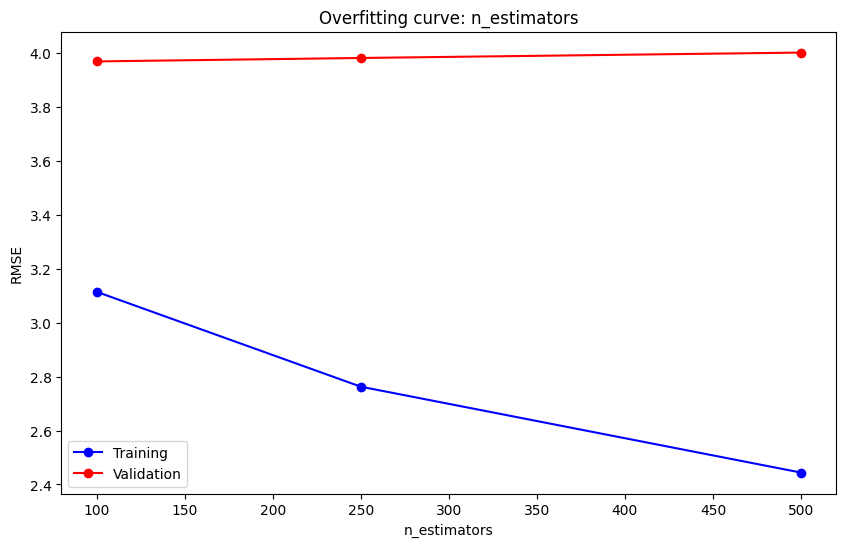

In [ ]:
%%time
test_param_and_plot(XGBRegressor, 'n_estimators', [100, 250, 500], **best_params)

## Max Depth

CPU times: user 25.5 s, sys: 53.9 ms, total: 25.5 s
Wall time: 17 s


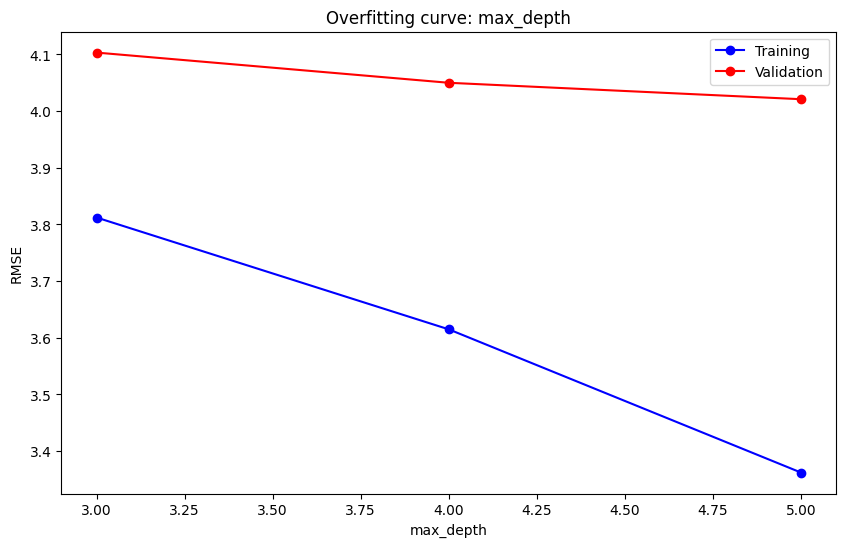

In [ ]:
%%time
test_param_and_plot(XGBRegressor, 'max_depth', [3, 4, 5], **best_params)

In [ ]:
best_params['max_depth'] = 5

## Learning Rate

CPU times: user 29.1 s, sys: 78.8 ms, total: 29.1 s
Wall time: 18.3 s


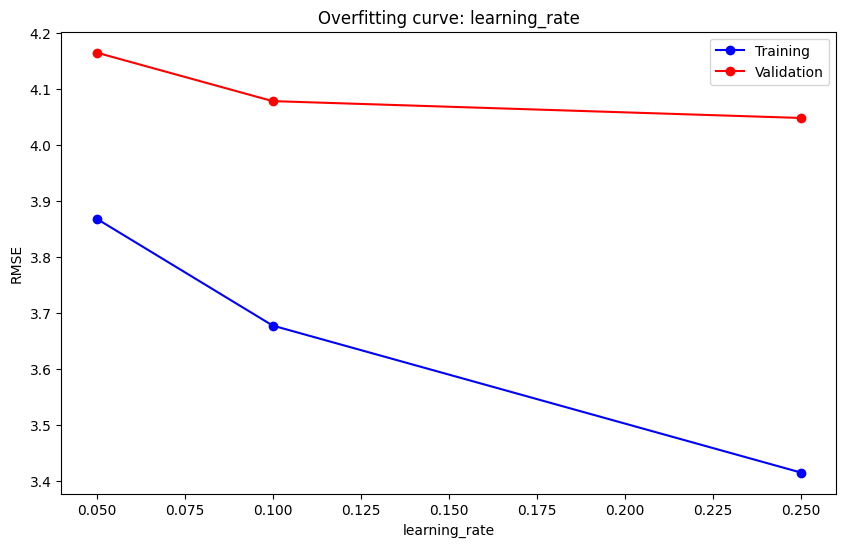

In [ ]:
%%time
test_param_and_plot(XGBRegressor, 'learning_rate', [0.05, 0.1, 0.25], **best_params)

In [ ]:
best_params['learning_rate'] = 0.25

## Other Parameters

In [ ]:
xgb_model_final = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42,
                               n_estimators=500, max_depth=5, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8)

In [ ]:
%%time
xgb_model_final.fit(train_inputs, train_targets)

CPU times: user 41.2 s, sys: 150 ms, total: 41.3 s
Wall time: 33.7 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
evaluate(xgb_model_final)

(np.float64(3.177574561660146),
 np.float64(3.9743583881134787),
 array([ 6.40014 ,  7.826713, 10.090213, ..., 11.700136,  9.153927,
        10.020915], dtype=float32),
 array([14.793883 ,  6.1466355, 48.299778 , ...,  7.6731853, 30.364616 ,
         8.587902 ], dtype=float32))

<Axes: title={'center': 'Model Comparison — NYC Taxi Fare Prediction'}, ylabel='Model'>

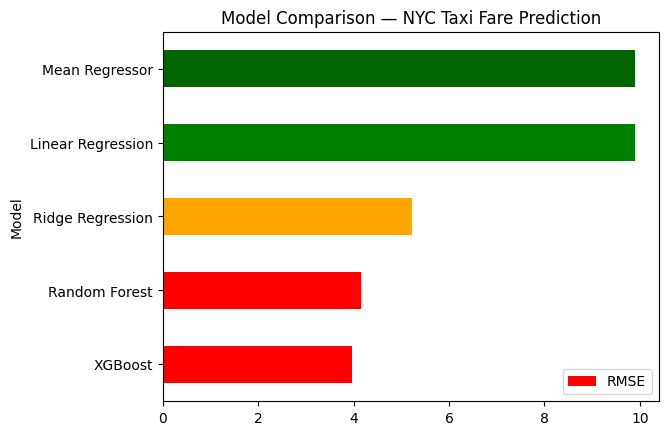

In [2]:
import pandas as pd
results = pd.DataFrame({
    'Model': ['Mean Regressor', 'Linear Regression',
              'Ridge Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [9.8999, 9.8980, 5.2178, 4.1631, 3.9677]
})
results.sort_values('RMSE').plot(
    kind='barh', x='Model', y='RMSE',
    title='Model Comparison — NYC Taxi Fare Prediction',
    color=['red','red','orange','green','darkgreen']
)